In [13]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon,spearmanr
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [14]:
animals = ['BS_40','BS_41','BS_42','BS_49','BS_50','BS_51','BS_56','BS_59','BS_67','BS_70','BS_72','BS_87','BS_108','DS_15','DS_19']

In [15]:
df = pd.read_csv('../../Source Data Files/Figure 2g.csv')

In [16]:
df

,Unnamed: 0,animal,session,cluster ID,learning phase,Stim decoding accuracy,FR modulation
0,0,BS_108,BS_108_1_AC.pickle,2,pre expert,0.565956,9.972452
1,1,BS_108,BS_108_1_AC.pickle,8,pre expert,0.720859,21.774194
2,2,BS_108,BS_108_1_AC.pickle,9,pre expert,0.560515,15.806452
3,3,BS_108,BS_108_1_AC.pickle,34,pre expert,0.641832,16.989247
4,4,BS_108,BS_108_2_AC.pickle,2,pre expert,0.570132,15.402299
...,...,...,...,...,...,...,...
479,479,DS_19,DS_19_1_AC.pickle,68,pre expert,0.684454,3.215130
480,480,DS_19,DS_19_1_AC.pickle,96,pre expert,0.613773,2.546064
481,481,DS_19,DS_19_20_AC.pickle,7,post expert,0.882687,3.661485
482,482,DS_19,DS_19_20_AC.pickle,8,post expert,0.836354,2.867012


In [17]:
CR_Stim_Dec_preearly = []
CR_Stim_Dec_prelate = []
CR_Stim_Dec_preexpert = []
CR_Stim_Dec_postearly = []
CR_Stim_Dec_postlate = []
CR_Stim_Dec_postexpert = []

NCR_Stim_Dec_preearly = []
NCR_Stim_Dec_prelate = []
NCR_Stim_Dec_preexpert = []
NCR_Stim_Dec_postearly = []
NCR_Stim_Dec_postlate = []
NCR_Stim_Dec_postexpert = []


for row in df.iloc():
    FRmod = row['FR modulation']
    tstim_acc = row['Stim decoding accuracy']
    
    if row['learning phase'] == 'pre early':
        if FRmod >= 3.5:
            CR_Stim_Dec_preearly.append(tstim_acc)
        else:
            NCR_Stim_Dec_preearly.append(tstim_acc)
    elif row['learning phase'] == 'pre late':
        if FRmod >= 3.5:
            CR_Stim_Dec_prelate.append(tstim_acc)
        else:
            NCR_Stim_Dec_prelate.append(tstim_acc)
    elif row['learning phase'] == 'pre expert':
        if FRmod >= 3.5:
            CR_Stim_Dec_preexpert.append(tstim_acc)
        else:
            NCR_Stim_Dec_preexpert.append(tstim_acc)
    elif row['learning phase'] == 'post early':
        if FRmod >= 3.5:
            CR_Stim_Dec_postearly.append(tstim_acc)
        else:
            NCR_Stim_Dec_postearly.append(tstim_acc)
    elif row['learning phase'] == 'post late':
        if FRmod >= 3.5:
            CR_Stim_Dec_postlate.append(tstim_acc)
        else:
            NCR_Stim_Dec_postlate.append(tstim_acc)
    elif row['learning phase'] == 'post expert':
        if FRmod >= 3.5:
            CR_Stim_Dec_postexpert.append(tstim_acc)
        else:
            NCR_Stim_Dec_postexpert.append(tstim_acc)
        
CR_Stim_Dec_preearly = (np.array(CR_Stim_Dec_preearly))
CR_Stim_Dec_prelate = (np.array(CR_Stim_Dec_prelate))
CR_Stim_Dec_preexpert = (np.array(CR_Stim_Dec_preexpert))
CR_Stim_Dec_postearly = (np.array(CR_Stim_Dec_postearly))
CR_Stim_Dec_postlate = (np.array(CR_Stim_Dec_postlate))
CR_Stim_Dec_postexpert = (np.array(CR_Stim_Dec_postexpert))

NCR_Stim_Dec_preearly = (np.array(NCR_Stim_Dec_preearly))
NCR_Stim_Dec_prelate = (np.array(NCR_Stim_Dec_prelate))
NCR_Stim_Dec_preexpert = (np.array(NCR_Stim_Dec_preexpert))
NCR_Stim_Dec_postearly = (np.array(NCR_Stim_Dec_postearly))
NCR_Stim_Dec_postlate = (np.array(NCR_Stim_Dec_postlate))
NCR_Stim_Dec_postexpert = (np.array(NCR_Stim_Dec_postexpert))




r_phase = []
p_phase = []
phases = ['pre early', 'pre late', 'pre expert', 'post early', 'post late', 'post expert']

for phase in phases:
    df_phase = df[df['learning phase']==phase]
    
    dec_accs = np.array(df_phase['Stim decoding accuracy'])
    mods = np.array(df_phase['FR modulation'])
    r,p = spearmanr(dec_accs,mods)

    r_phase.append(r)
    p_phase.append(p)
    
        

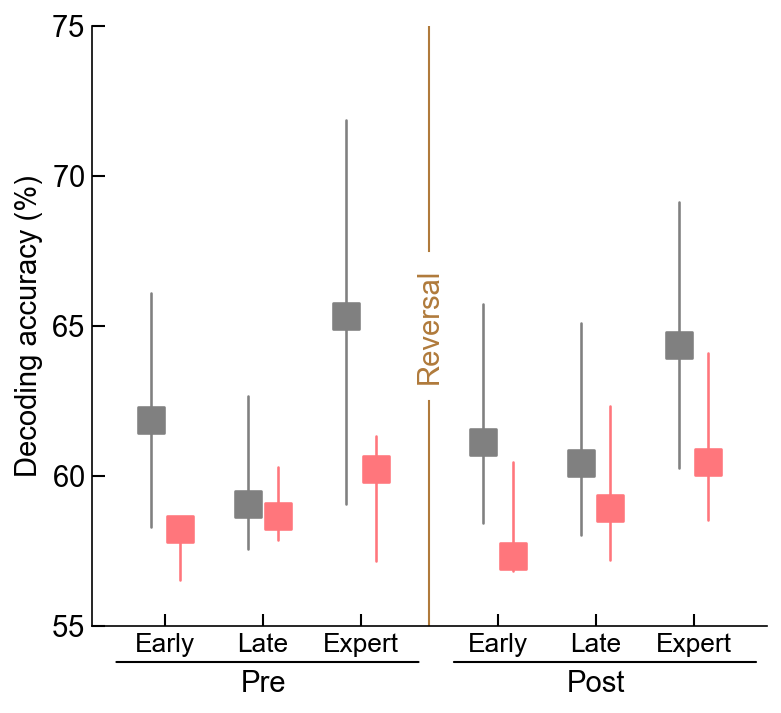

In [18]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(4.5, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0.2
wid = 0.15

################################################################################################################

for idx,(CR_Stim_Dec,p) in enumerate(zip([CR_Stim_Dec_preearly,CR_Stim_Dec_prelate,CR_Stim_Dec_preexpert,CR_Stim_Dec_postearly,CR_Stim_Dec_postlate,CR_Stim_Dec_postexpert],[-1,-1,-1,1,1,1])):
    Q1, median, Q3 = (np.percentile(ilep.rmnan(CR_Stim_Dec)*100, q) for q in [25, 50, 75])
    summary_size=150
    summary_width=1.25
    eye_color=CR_COLOR
    border_color=CR_COLOR
    ax.scatter([idx-wid+p*switch_offset], [median], ec=border_color,fc=eye_color, s=summary_size,lw=summary_width, marker='s', zorder=10)
    ax.plot([idx+-wid+p*switch_offset]*2, [Q1, Q3], c=border_color, lw=summary_width, zorder=9, solid_capstyle='round')

for idx,(NCR_Stim_Dec,p) in enumerate(zip([NCR_Stim_Dec_preearly,NCR_Stim_Dec_prelate,NCR_Stim_Dec_preexpert,NCR_Stim_Dec_postearly,NCR_Stim_Dec_postlate,NCR_Stim_Dec_postexpert],[-1,-1,-1,1,1,1])):
    Q1, median, Q3 = (np.percentile(ilep.rmnan(NCR_Stim_Dec)*100, q) for q in [25, 50, 75])
    summary_size=150
    summary_width=1.25
    eye_color=NCR_COLOR
    border_color=NCR_COLOR
    ax.scatter([idx+wid+p*switch_offset], [median], ec=border_color,fc=eye_color, s=summary_size,lw=summary_width, marker='s', zorder=10)
    ax.plot([idx+wid+p*switch_offset]*2, [Q1, Q3], c=border_color, lw=summary_width, zorder=9, solid_capstyle='round')

################################################################################################################
labels = ['Early','Late','Expert','Early','Late','Expert']

ax.set_ylim([55,75])
ax.set_yticks([55,60,65,70,75])
ylab = ax.set_ylabel('Decoding accuracy (%)')

ax.set_xlim([-0.75-switch_offset,5.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset,3+switch_offset,4+switch_offset,5+switch_offset])
ax.set_xticklabels(labels)

xtick_pos_pre = ax.get_xticks()[1]
xtick_pos_post = ax.get_xticks()[4]
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac,log=False)
t1 = ax.text(xtick_pos_pre, Yval, 'Pre', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Post', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.03, -stdyfrac), xycoords='axes fraction', xytext=(0.49, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.53, -stdyfrac), xycoords='axes fraction', xytext=(0.99, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

Y = np.mean(ax.get_ylim())
t = ax.text(2.5,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
ax.plot([2.5]*2,[ax.get_ylim()[0],Y-np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)
ax.plot([2.5]*2,[ax.get_ylim()[1],Y+np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)

artists = [ylab,t1,t2]

# fig.savefig(os.path.join('..','..','Figures','Figure 2g.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [21]:
CRs = [CR_Stim_Dec_preearly,CR_Stim_Dec_prelate,CR_Stim_Dec_preexpert,CR_Stim_Dec_postearly,CR_Stim_Dec_postlate,CR_Stim_Dec_postexpert]
CRs = [ilep.rmnan(d) for d in CRs]
NCRs = [NCR_Stim_Dec_preearly,NCR_Stim_Dec_prelate,NCR_Stim_Dec_preexpert,NCR_Stim_Dec_postearly,NCR_Stim_Dec_postlate,NCR_Stim_Dec_postexpert]
NCRs = [ilep.rmnan(d) for d in NCRs]


p1 = mannwhitneyu(CRs[0],NCRs[0]).pvalue
p2 = mannwhitneyu(CRs[1],NCRs[1]).pvalue
p3 = mannwhitneyu(CRs[2],NCRs[2]).pvalue
p4 = mannwhitneyu(CRs[3],NCRs[3]).pvalue
p5 = mannwhitneyu(CRs[4],NCRs[4]).pvalue
p6 = mannwhitneyu(CRs[5],NCRs[5]).pvalue

pvals = [p1,p2,p3,p4,p5,p6]

_,pvals_corr = pg.multicomp(pvals,method='fdr_bh')
print(f'Pre-early  : {pvals_corr[0]}')
print(f'Pre-late   : {pvals_corr[1]}')
print(f'Pre-expert : {pvals_corr[2]}\n')

print(f'Post-early : {pvals_corr[3]}')
print(f'Post-late  : {pvals_corr[4]}')
print(f'Post-expert: {pvals_corr[5]}\n')

Pre-early  : 0.018800045974481483
Pre-late   : 0.7989066696432698
Pre-expert : 0.018800045974481483

Post-early : 0.0017231749365372547
Post-late  : 0.14759998280435482
Post-expert: 0.02247850449269472

